In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as th
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GATConv, GCNConv, SAGEConv

/usr/lib/python3/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Données générées par le notebook 0_import_data (split train / val / test fait )

train_data = th.load('../data/train_data_norm.pt', weights_only=False)
val_data = th.load('../data/val_data_norm.pt', weights_only=False)
test_data = th.load('../data/test_data_norm.pt', weights_only=False)
data = th.load('../data/data.pt', weights_only=False)

# on vérifie les données chargées
print(test_data)
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {data.num_features} features")
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {train_data.num_features} features")

# Paramètres communs à toutes les expériences, cest paramètres pourront varier localement selon les besoins
HIDDEN, DIM_OUT, EPOCHS, LR = 32, 16, 200, 0.01
SEEDS = [0, 1, 2]

Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])

Features des nœuds : [longitude, latitude, population] -> 3 features

Features des nœuds : [longitude, latitude, population] -> 216 features


In [3]:
# Définition de l'encodeur et des fonctions d'entraînement et de test pour les modèles


class Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, conv=GCNConv):
        super(Encoder, self).__init__()
        self.conv1 = conv(dim_in, hidden_channels)
        self.conv_mu = conv(hidden_channels, dim_out)
        self.conv_logstd = conv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd


def entrainer_et_tester(model, optimizer, epochs, train_data, val_data, test_data):
    history = {"train": [], "val": []}
    meilleure_auc_val, meilleur_etat = -1, None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        loss = model.recon_loss(
            z, train_data.pos_edge_label_index, train_data.neg_edge_label_index
        ) + model.kl_loss() / train_data.num_nodes
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())

        # validation : pas de calcul de gradient mais on calcule la loss sur les données de validation
        model.eval()
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index
            ) + model.kl_loss() / val_data.num_nodes
            history["val"].append(val_loss.item())
            auc_val, _ = model.test(z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index)
            if auc_val > meilleure_auc_val:
                meilleure_auc_val, meilleur_etat = auc_val, copy.deepcopy(model.state_dict())

    # évaluation sur le test avec le meilleur modèle (choisi sur la validation)
    model.load_state_dict(meilleur_etat)
    model.eval()
    with th.no_grad():
        z_test = model.encode(test_data.x, test_data.edge_index)
        auc_test, ap_test = model.test(z_test, test_data.pos_edge_label_index, test_data.neg_edge_label_index)
    return history, auc_test, ap_test


def lancer_experience(splits, conv=GCNConv, hidden_channels=HIDDEN, dim_out=DIM_OUT, EPOCHS=EPOCHS, LR=LR):
    # un entraînement par seed ; renvoie les résultats test, l'historique et le modèle de la première seed
    resultats, historique, modele = [], None, None
    for seed in SEEDS:
        th.manual_seed(seed)
        model = VGAE(Encoder(splits[0].num_features, hidden_channels, dim_out, conv))
        optimizer = th.optim.Adam(model.parameters(), lr=LR)
        history, auc, ap = entrainer_et_tester(model, optimizer, EPOCHS, *splits)
        resultats.append({"seed": seed, "AUC": auc, "AP": ap})
        if seed == SEEDS[0]:
            historique, modele = history, model
    return resultats, historique, modele

In [4]:
splits_bruts = (train_data, val_data, test_data)
dimensions = {
    "GCN model_a (32 → 16)": (32, 16),
    "GCN model_b (128 → 16)": (128, 16),
    "GCN model_c (6 → 6)": (6, 6),
}

# Expérimentation sur différentes dimensions des modèles VGAE
EPOCHS_vgae=50 # le nombre d'epoch optimal a été trouvé après plusieurs tests (en comparant les performances sur la validation et le training)
resultats_dim, historiques_dim, modeles_dim = [], {}, {}
for nom, (hidden_channels, dim_out) in dimensions.items():
    resultats, historiques_dim[nom], modeles_dim[nom] = lancer_experience(
        splits_bruts, GCNConv, hidden_channels, dim_out, EPOCHS=EPOCHS_vgae, LR=LR)
    resultats_dim += [{"modele": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))



GCN model_a (32 → 16) : AUC test = 0.9706, 0.9733, 0.9719
GCN model_b (128 → 16) : AUC test = 0.9757, 0.9753, 0.9751
GCN model_c (6 → 6) : AUC test = 0.9341, 0.8965, 0.8989


In [5]:
convs = {"GCN (32 → 16)": GCNConv, "GAT (32 → 16)": GATConv, "SAGE (32 → 16)": SAGEConv}

EPOCHS_convs=50 # le nombre d'epoch optimal a été trouvé après plusieurs tests (en comparant les performances sur la validation et le training)

resultats_convs, historiques_convs, modeles_convs = [], {}, {}
for nom, conv in convs.items():
    resultats, historiques_convs[nom], modeles_convs[nom] = lancer_experience(splits_bruts, conv, EPOCHS=EPOCHS_convs, LR=LR)
    resultats_convs += [{"couche": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))



GCN (32 → 16) : AUC test = 0.9706, 0.9733, 0.9719
GAT (32 → 16) : AUC test = 0.9235, 0.9249, 0.9226
SAGE (32 → 16) : AUC test = 0.9249, 0.9227, 0.9247


In [6]:
print(modeles_convs)
print(modeles_dim)


from torch import save
# sauvegarde des modèles et des résultats , comment faire ?


save(modeles_convs, "../resultats/modeles_convs.pth")

save(modeles_dim, "../resultats/modeles_dim.pth")
save(resultats_convs, "../resultats/resultats_convs.pth")
save(resultats_dim, "../resultats/resultats_dim.pth")




# on 

{'GCN (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'GAT (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GATConv(216, 32, heads=1)
    (conv_mu): GATConv(32, 16, heads=1)
    (conv_logstd): GATConv(32, 16, heads=1)
  )
  (decoder): InnerProductDecoder()
), 'SAGE (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): SAGEConv(216, 32, aggr=mean)
    (conv_mu): SAGEConv(32, 16, aggr=mean)
    (conv_logstd): SAGEConv(32, 16, aggr=mean)
  )
  (decoder): InnerProductDecoder()
)}
{'GCN model_a (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'GCN model_b (128 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(216, 128)
    (conv_mu): GCNConv(128, 16)
    (conv_logstd): GCNConv(128, 16)
  )
  (decoder): InnerProductDecoder()
),

In [7]:
# on définit plusieurs fonctions pour analyser les résultats

def resumer(df, colonnes):
    # moyenne et écart-type sur les seeds
    return df.groupby(colonnes, sort=False)[["AUC", "AP"]].agg(["mean", "std"]).round(4)


def tracer_barres(df, col_groupe, col_serie=None, titre="", ylim=(0.4, 1.03)):
    # barres AUC / AP (moyenne ± écart-type sur les seeds) + ligne de la baseline distance (section 1)
    if col_serie is None:
        df = df.assign(_serie="VGAE")
        col_serie = "_serie"
    stats = df.groupby([col_groupe, col_serie], sort=False)[["AUC", "AP"]].agg(["mean", "std"])
    groupes = list(dict.fromkeys(df[col_groupe]))
    series = list(dict.fromkeys(df[col_serie]))
    largeur = 0.8 / len(series)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metrique in zip(axes, ["AUC", "AP"]):
        for i, serie in enumerate(series):
            positions = [g + (i - (len(series) - 1) / 2) * largeur for g in range(len(groupes))]
            moyennes = [stats.loc[(g, serie), (metrique, "mean")] for g in groupes]
            ecarts = [stats.loc[(g, serie), (metrique, "std")] for g in groupes]
            barres = ax.bar(positions, moyennes, largeur, yerr=ecarts, capsize=3,
                            label=serie if col_serie != "_serie" else None)
            ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=7)
        #ax.axhline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1, label="baseline distance")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="hasard")
        ax.set_xticks(range(len(groupes)), groupes)
        ax.set_ylim(*ylim)
        ax.set_title(f"{metrique} test — {titre}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def tracer_loss(historiques, titre):
    # courbes de loss train (trait plein) et validation (pointillés), échelle log
    plt.figure(figsize=(8, 4))
    for nom, history in historiques.items():
        ligne, = plt.plot(history["train"], label=f"{nom} train")
        plt.plot(history["val"], linestyle="--", color=ligne.get_color(), label=f"{nom} val")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (échelle log)")
    plt.title(titre)
    plt.legend(fontsize=8)
    plt.show()


def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    with th.no_grad():
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Récupération de toutes les arêtes positives et négatives
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf = lemodele.test(z, pos_edges, neg_edges)
        predictions = (probabilites >= 0.9).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[0]:.4f} (vrai_positif/faux_positif) - AP {perf[1]:.4f} ( précision/rappel )")

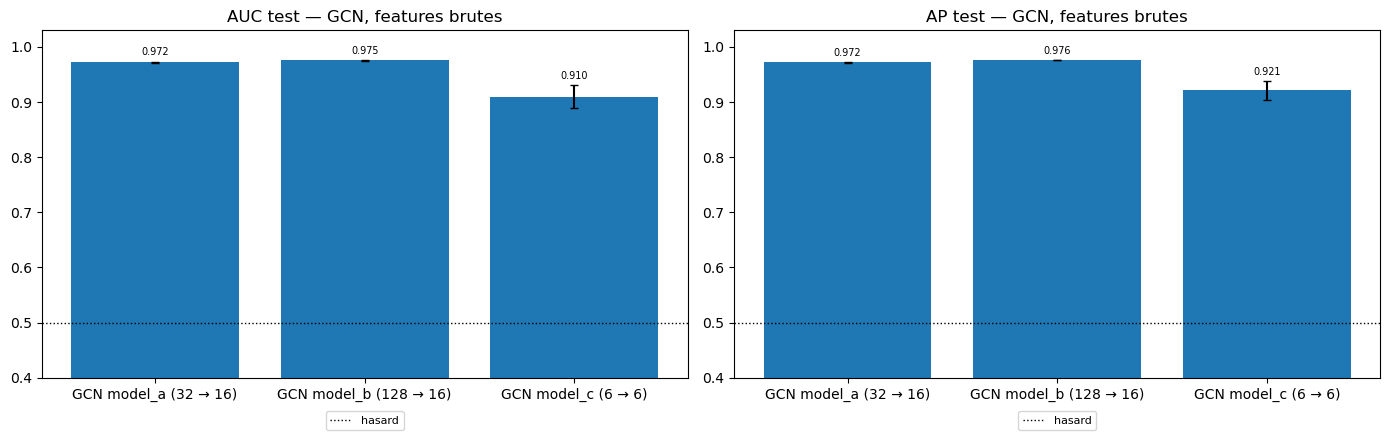

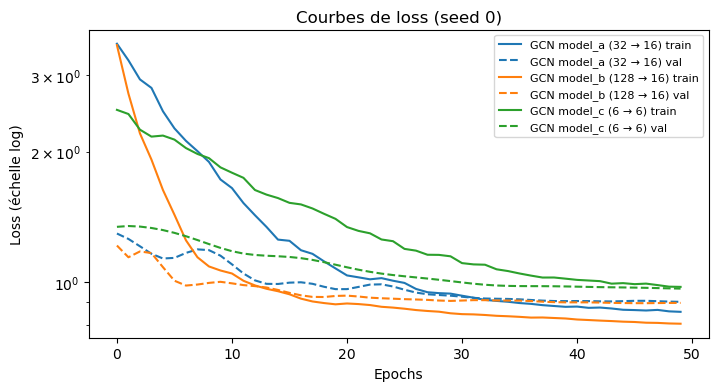


Matrice de confusion — GCN model_a (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2653   56]
 [ 799 1910]]
Perf : AUC 0.9706 (vrai_positif/faux_positif) - AP 0.9706 ( précision/rappel )

Matrice de confusion — GCN model_b (128 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2658   51]
 [ 725 1984]]
Perf : AUC 0.9757 (vrai_positif/faux_positif) - AP 0.9759 ( précision/rappel )

Matrice de confusion — GCN model_c (6 → 6) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2673   36]
 [1177 1532]]
Perf : AUC 0.9341 (vrai_positif/faux_positif) - AP 0.9412 ( précision/rappel )


In [8]:
df_dimensions = pd.DataFrame(resultats_dim)

tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
tracer_loss(historiques_dim, "Courbes de loss (seed 0)")

for nom, model in modeles_dim.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")



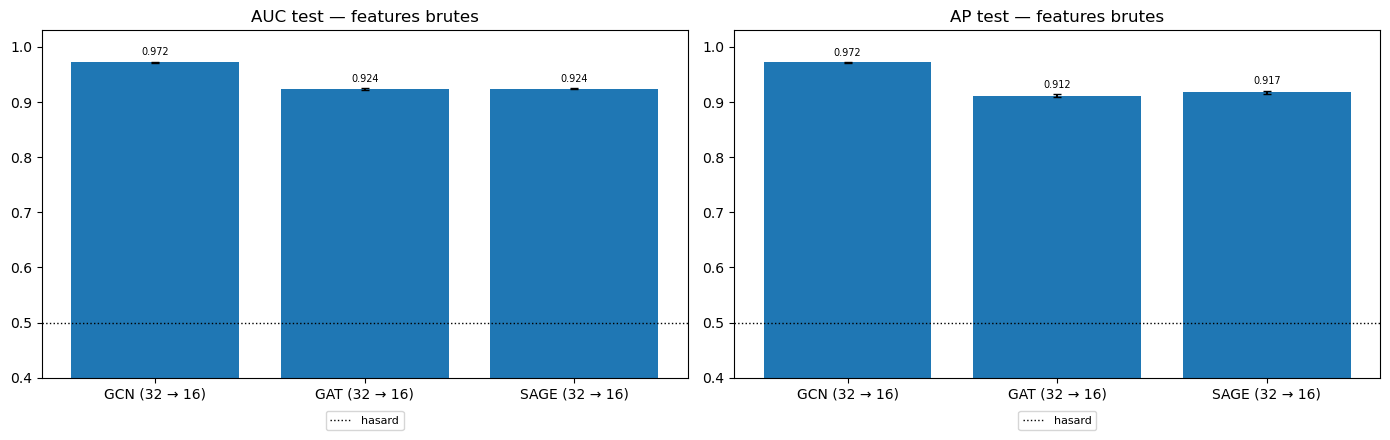

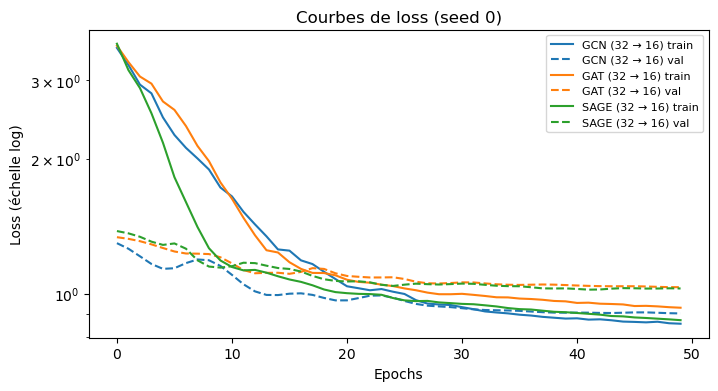


Matrice de confusion — GCN (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2653   56]
 [ 799 1910]]
Perf : AUC 0.9706 (vrai_positif/faux_positif) - AP 0.9706 ( précision/rappel )

Matrice de confusion — GAT (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2619   90]
 [1339 1370]]
Perf : AUC 0.9235 (vrai_positif/faux_positif) - AP 0.9139 ( précision/rappel )

Matrice de confusion — SAGE (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2582  127]
 [1042 1667]]
Perf : AUC 0.9249 (vrai_positif/faux_positif) - AP 0.9211 ( précision/rappel )


In [9]:
# on affiche les résultats pour conv

df_convs = pd.DataFrame(resultats_convs)
tracer_barres(df_convs, "couche", titre="features brutes")
tracer_loss(historiques_convs, "Courbes de loss (seed 0)")
for nom, model in modeles_convs.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")

In [10]:
print("Construction des modèles terminée.")

Construction des modèles terminée.


In [11]:
from torch_geometric.nn import GAE, GCNConv


class GAEEncoder3Layers(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out):
        super().__init__()
        self.conv1 = GCNConv(dim_in, dim_out)
        #self.conv1 = GCNConv(dim_in, hidden_channels)
        #self.conv2 = GCNConv(hidden_channels, hidden_channels)
        #self.conv3 = GCNConv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        #x = self.conv2(x, edge_index).relu()
        #x = self.conv3(x, edge_index)
        return x


resultats_gae_3_couches = []
modeles_gae_3_couches = {}
EPOCHS_GAE = 50

for seed in SEEDS:
    th.manual_seed(seed)
    modele = GAE(
        GAEEncoder3Layers(train_data.num_features, HIDDEN, DIM_OUT)
    )
    optimiseur = th.optim.Adam(modele.parameters(), lr=LR)
    meilleur_auc_val = -1.0
    meilleur_etat = None

    for epoch in range(EPOCHS_GAE):
        modele.train()
        optimiseur.zero_grad()
        z = modele.encode(train_data.x, train_data.edge_index)
        perte = modele.recon_loss(
            z, train_data.pos_edge_label_index, train_data.neg_edge_label_index
        )
        perte.backward()
        optimiseur.step()

        modele.eval()
        with th.no_grad():
            z_val = modele.encode(val_data.x, val_data.edge_index)
            auc_val, _ = modele.test(
                z_val,
                val_data.pos_edge_label_index,
                val_data.neg_edge_label_index,
            )
            if auc_val > meilleur_auc_val:
                meilleur_auc_val = auc_val
                meilleur_etat = copy.deepcopy(modele.state_dict())

    modele.load_state_dict(meilleur_etat)
    modele.eval()
    print(f"Meilleur AUC sur la validation pour la seed {seed} : {meilleur_auc_val}")
    
    with th.no_grad():
        z_test = modele.encode(test_data.x, test_data.edge_index)
        auc_test, ap_test = modele.test(
            z_test,
            test_data.pos_edge_label_index,
            test_data.neg_edge_label_index,
        )

    modeles_gae_3_couches[seed] = modele
    resultats_gae_3_couches.append(
        {"seed": seed, "AUC": auc_test, "AP": ap_test}
    )

resultats_gae_3_couches = pd.DataFrame(resultats_gae_3_couches)
print("Résultats GAE à 3 couches sur le jeu de test :")
print(resultats_gae_3_couches.round(4).to_string(index=False))
print("\nMoyenne et écart-type sur les seeds :")
print(resultats_gae_3_couches[["AUC", "AP"]].agg(["mean", "std"]).round(4))




Meilleur AUC sur la validation pour la seed 0 : 0.9561035849793489
Meilleur AUC sur la validation pour la seed 1 : 0.9613754530042831
Meilleur AUC sur la validation pour la seed 2 : 0.9572921416711577
Résultats GAE à 3 couches sur le jeu de test :
 seed    AUC     AP
    0 0.9620 0.9621
    1 0.9649 0.9642
    2 0.9643 0.9649

Moyenne et écart-type sur les seeds :
         AUC      AP
mean  0.9638  0.9637
std   0.0015  0.0014
